### E-Commerce Business Analysis

In [1]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import seaborn as sn
import plotly.express as px
import kagglehub
import seaborn as sns
print("listo librerias")

listo librerias


d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Extrar desde kaggle: https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Josefina Urquiza\.cache\kagglehub\datasets\umuttuygurr\e-commerce-customer-behavior-and-sales-analysis-tr\versions\2


In [2]:
# El link se saca de lo que me dice kaggle antes
df = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr/versions/2/ecommerce_customer_behavior_dataset_v2.csv")

df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


In [10]:
# Configuracion SQL
%load_ext sql

print("Configuracion y librerias OK")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
Configuracion y librerias OK


In [11]:
# Usar un archivo como SQLite como base de datos
database_filename = 'ecommerce_customer_behavior.db'
df.to_sql('ecommerce_customer_behavior', f'sqlite:///{database_filename}', if_exists='replace', index=False)

# Conexion a la base de datos generada
%sql sqlite:///ecommerce_customer_behavior.db

#Configuracion de sql (revisar)
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [12]:
# Primera consulta, mostrar la data y ver si funciona el sql
%sql SELECT * FROM ecommerce_customer_behavior LIMIT 10;

 * sqlite:///ecommerce_customer_behavior.db
   sqlite:///ecommerce_sales_data.db
Done.


Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.0,29.18,Digital Wallet,Mobile,14,9,1,13,4
ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.4,1,138.05,506.35,Credit Card,Desktop,14,8,1,6,2
ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.0,1664.1,Credit Card,Mobile,15,10,1,9,4
ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.3,5,71.05,275.45,Digital Wallet,Desktop,16,13,1,4,4
ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.0,534.45,Credit Card,Mobile,14,7,1,6,4
ORD_000003-1,CUST_00003,2023-02-27,42,Male,Konya,Toys,198.28,2,0.0,396.56,Credit Card,Tablet,10,9,0,6,2
ORD_000003-2,CUST_00003,2024-01-03,42,Male,Konya,Home & Garden,526.85,5,0.0,2634.25,Digital Wallet,Desktop,11,8,1,6,5
ORD_000004-1,CUST_00004,2024-02-13,53,Male,Izmir,Fashion,96.2,5,97.78,383.22,Credit Card,Desktop,16,15,0,4,5
ORD_000005-1,CUST_00005,2023-03-16,32,Male,Ankara,Home & Garden,533.67,3,0.0,1601.01,Bank Transfer,Mobile,12,8,0,5,5
ORD_000005-2,CUST_00005,2023-06-12,32,Male,Ankara,Toys,73.06,4,0.0,292.24,Credit Card,Mobile,13,12,1,7,2


####  01. Analisis exploratorio general del dataset
Primero es necesario entender bien el dataset.

In [3]:
# Algunas metricas estadisticas basicas y de exploracion general del dataset()
print(df.info())
#No hay nulos ni duplicados
# df.isnull().sum()
# df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  str    
 1   Customer_ID               17049 non-null  str    
 2   Date                      17049 non-null  str    
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  str    
 5   City                      17049 non-null  str    
 6   Product_Category          17049 non-null  str    
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  str    
 12  Device_Type               17049 non-null  str    
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_Viewed     

In [17]:
print(df.describe())


                Age    Unit_Price      Quantity  Discount_Amount  \
count  17049.000000  17049.000000  17049.000000     17049.000000   
mean      34.945745    447.901689      3.011379        69.788135   
std       11.046855    722.319705      1.417027       240.704662   
min       18.000000      5.050000      1.000000         0.000000   
25%       26.000000     73.260000      2.000000         0.000000   
50%       35.000000    174.680000      3.000000         0.000000   
75%       42.000000    494.570000      4.000000        32.710000   
max       75.000000   7900.010000      5.000000      6538.290000   

       Total_Amount  Session_Duration_Minutes  Pages_Viewed  \
count  17049.000000              17049.000000  17049.000000   
mean    1277.438711                 14.535633      9.003109   
std     2358.436375                  2.925524      2.259954   
min        6.210000                  4.000000      1.000000   
25%      172.970000                 13.000000      7.000000   
50%      

In [ ]:
#Configurar la fecha
df["Date"] = pd.to_datetime(df["Date"])
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


Desglose del dataset

Las variables se pueden dividir en 4 bloques:

1.	Perfil del cliente:
   - Age
   - Gender
   - City
2.	Comportamiento de compra
   - Product_Category
   - Unit_Price
   - Quantity
   - Discount_Amount
   - Total_Amount
3.	Comportamiento digital
   - Device_Type
   - Session_Duration
   - Pages_Viewed
4.	Experiencia post-compra
   - Delivery_Time
   - Customer_Rating
   - Is_Returning_Customer


## Analisis 1° bloque: 

1.	Perfil del cliente:
   - Age
   - Gender
   - City

### Variable: AGE
¿Qué queremos entender?
- Distribución de edades
- Si hay concentración en algún rango
- Si el negocio está orientado a un público joven, adulto, etc

count    17049.000000
mean        34.945745
std         11.046855
min         18.000000
25%         26.000000
50%         35.000000
75%         42.000000
max         75.000000
Name: Age, dtype: float64


<Axes: title={'center': 'Distribución de Edad'}, xlabel='Age_Group', ylabel='Count'>

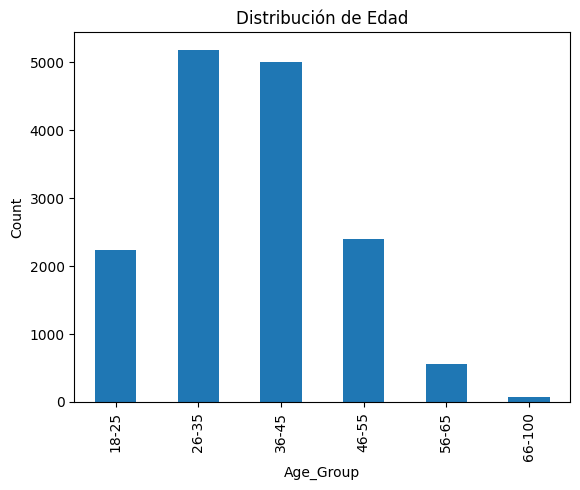

In [10]:
# Estadísticos básicos
print(df["Age"].describe())
#Plot de distribucion
sns.histplot(df["Age"], bins=20)
plt.title("Distribución de Edad")

##################################
#Plot de distribucion por bins
bins = [18, 25, 35, 45, 55, 65,100]
labels = ["18-25","26-35","36-45","46-55","56-65", "66-100"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

df["Age_Group"].value_counts().sort_index().plot(kind="bar")


Resumen
- La edad minima es de 18 años (solo mayores de edad)
- La mayor proporcion esta entre 26-45 años, es decir un publico joven-adulto
- Poblacion economicamente activa
- Media vs Mediana: la distribucion es bastante simetrica y no presenta sesgos fuertes
- El max de edad que compro fue de 72
- Es un e-commerce de aultos jovenes con cierto poder adquisitivo 

### Variable: GENDER 
¿Qué queremos entender?
- Es variable categórica.
- Proporción hombres vs mujeres
- Si está balanceado el público

Gender
Female    0.505191
Male      0.479559
Other     0.015250
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Distribución por Género')

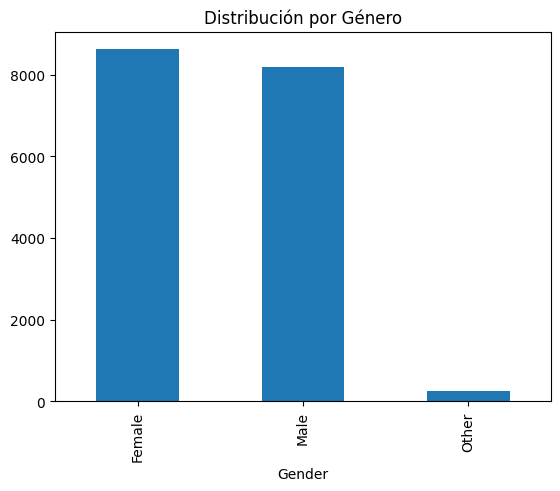

In [12]:
#Contamos cuantos hay de cada genero
print(df["Gender"].value_counts(normalize=True))
#Plot
df["Gender"].value_counts().plot(kind="bar")
plt.title("Distribución por Género")

Resumen:
- Distribución  equilibrada.
- No es un e-commerce claramente orientado a un solo género.
- Permite estrategias de segmentación más fina
- El grupo Other (1.5%) es pequeño pero existe. Podria ser importante desde el punto de vista de inclusión y segmentación futura.

##### Variable: city 
Qué queremos entender?
- Está concentrado en pocas ciudades?
- Es un negocio nacional o concentrado



City
Istanbul     4402
Ankara       2422
Izmir        2072
Bursa        1721
Adana        1326
Antalya      1246
Gaziantep    1183
Konya        1120
Kayseri       851
Eskisehir     706
Name: count, dtype: int64
Valor:  0.5217901343187284


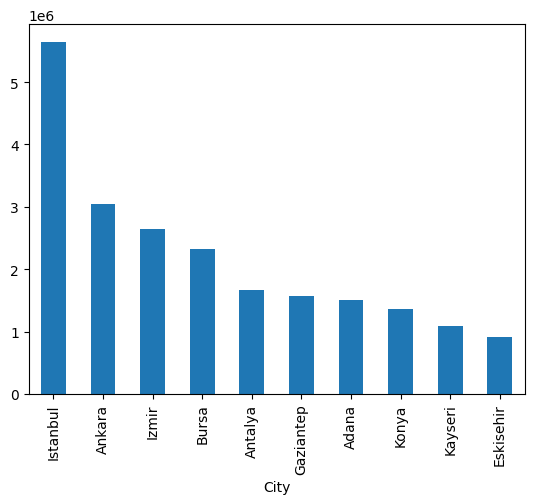

In [21]:
# En cuantas ciudades esta el negocio, llega el negocio o son los clientes
print(df["City"].value_counts())
####
# Plot 1
#df["City"].value_counts().plot(kind="bar")
#plt.title("Top 10 ciudades por cantidad de órdenes")
#Plot 2
df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False).plot(kind="bar")

top3 = df["City"].value_counts(normalize=True).head(3).sum()
print("Valor: ",top3)

- El negocio ocurre en distintas ciudades de Turquia
- Esto corresponde a cantidad de compras
- Estanbul corresponde al 26% de las compras
- Hay 3 ciudades que dominnan y el resto de menor participacion


## Analisis exploratorio del 2° Bloque: Comportamiento de compra
   - Product_Category
   - Unit_Price
   - Quantity
   - Discount_Amount
   - Total_Amount

##### Variable: Product_Category (categórica)
Qué queremos entender?
- Cantidad de órdenes por categoría
- Proporción sobre el total
- Distribución (¿está concentrado o equilibrado?)

Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64


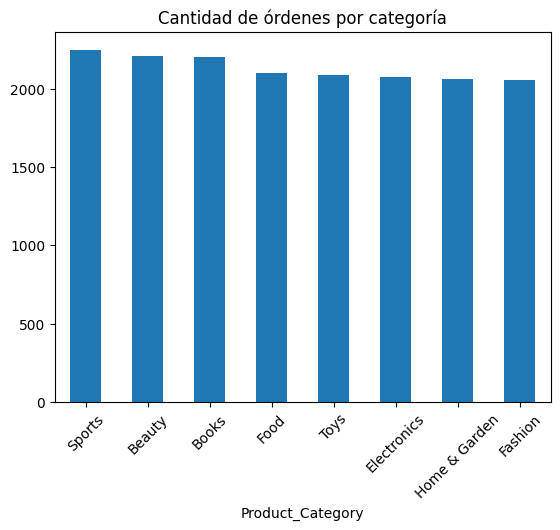

In [25]:
# Cantidad
print(df["Product_Category"].value_counts())
df["Product_Category"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Cantidad de órdenes por categoría")
plt.xticks(rotation=45)
plt.show()

- La distribucion de compra de las categorias son bastante homogeneas entre 12-13% cada uno. Un poco mas sports pero no hay diferencias significativas.
- Son 8 las categorias que hay: Sports; Beauty; Books; Food; Toys; Electronics; Home & Garden; Fashion.
- La diferencia entre la categoría con más órdenes (Sports: 2248) y la de menos (Fashion: 2056) es muy pequeña.
- El volumen de ventas está bastante distribuido.
- No hay una categoría dominante en cantidad de órdenes.
- El negocio no depende del volumen de una sola categoría.

In [ ]:
total = 17049 
Sports =         (2248 / total)*100
Beauty  =        ( 2212/ total)*100
Books    =       ( 2206/ total)*100
Food      =      ( 2103/ total)*100
Toys       =     ( 2090/ total)*100
Electronics =    ( 2074 / total)*100
Home =    ( 2060/ total)*100
Fashion =   (  2056/ total)*100

print(Sports)
print(Beauty)
print(Books)
print(Food)
print(Toys)
print(Electronics)
print(Home)
print(Fashion)


13.185524077658513
12.974367998123057
12.93917531820048
12.335034312862925
12.25878350636401
12.164936359903807
12.082820106751129
12.059358320136077


96

##### Variable: Unit_Price (precio unitario)
- Que ver como es el precio de las categorias

count    17049.000000
mean       447.901689
std        722.319705
min          5.050000
25%         73.260000
50%        174.680000
75%        494.570000
max       7900.010000
Name: Unit_Price, dtype: float64


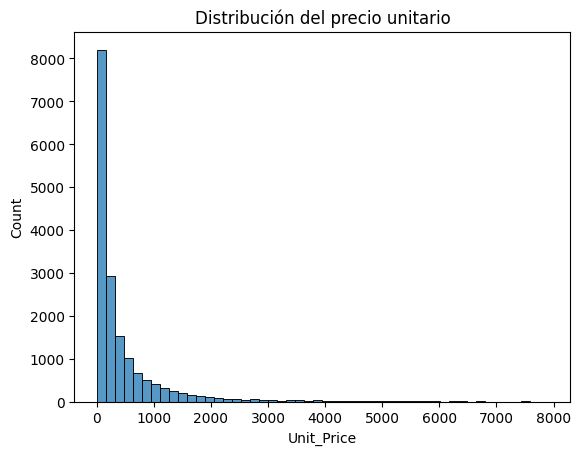

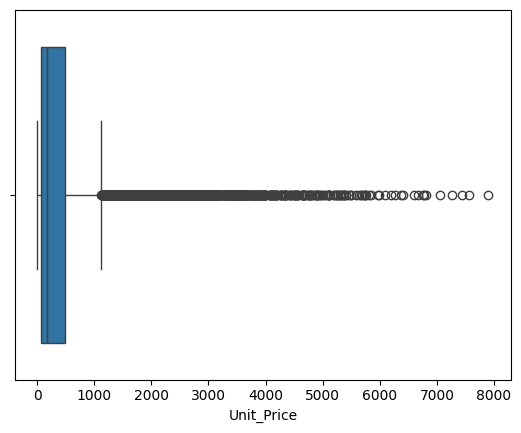

In [31]:
#Estadistica basica
print(df["Unit_Price"].describe())

#Distribucion de los precios
sns.histplot(df["Unit_Price"], bins=50)
plt.title("Distribución del precio unitario")
plt.show()

# Para ver outliers
sns.boxplot(x=df["Unit_Price"])
plt.show()

Resumen

- Fuerte asimetría positiva. La media es mucho mayor que la mediana. Esto hace que los productos extremadamente caros eleven el promedio.
- La mayoría de los productos están por debajo de 200–300.
- Alta dispersion, sd es miu altorespecto a la media lo que indica mezcla de productos muy baratos hasta muy caros
- Presencia de outliers fuertes: el max es 15 veces la media
- Para análisis de negocio conviene usar mediana o segmentar por categoría por la alta dispersión


##### Variable: Quantity (cantidad comprada)
- Que ver como es el precio de las categorias
- ¿Predomina comprar 1 unidad?
- ¿Está equilibrado?
- ¿Hay sesgo hacia compras pequeñas?

count    17049.000000
mean         3.011379
std          1.417027
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Quantity, dtype: float64


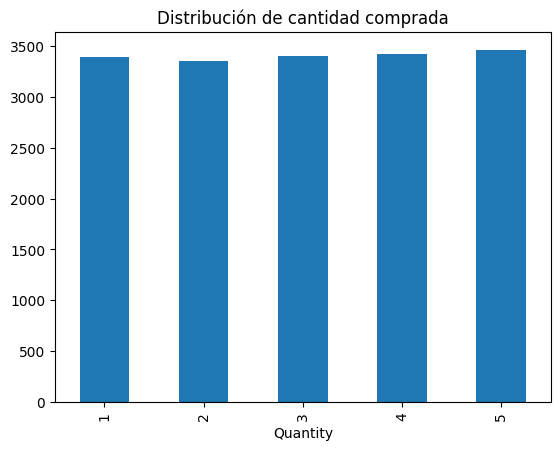

In [32]:
#Estadistica basica
print(df["Quantity"].describe())
#Plot de cantidad
df["Quantity"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de cantidad comprada")
plt.show()

Resumen
- El valor va de 1 - 5, la mediana es 3
- Es uniforme la distibucion de la cantidad de compra no hay diferencias notables
- No hay un sesgo hacia compras mas pqueñas o mas altas es uniforme el patron de compra
- N hay outliers
- La mediana es 3, lo que indica que un cliente típico compra 3 unidades

##### Variable: Discount_Amount (descuento)

 Que queremos entender:
 - ¿Cuántas órdenes tienen descuento?
- ¿Qué tan grandes son los descuentos?
- ¿Hay valores extremos?
- ¿Podría estar afectando la rentabilidad?

count    17049.000000
mean        69.788135
std        240.704662
min          0.000000
25%          0.000000
50%          0.000000
75%         32.710000
max       6538.290000
Name: Discount_Amount, dtype: float64


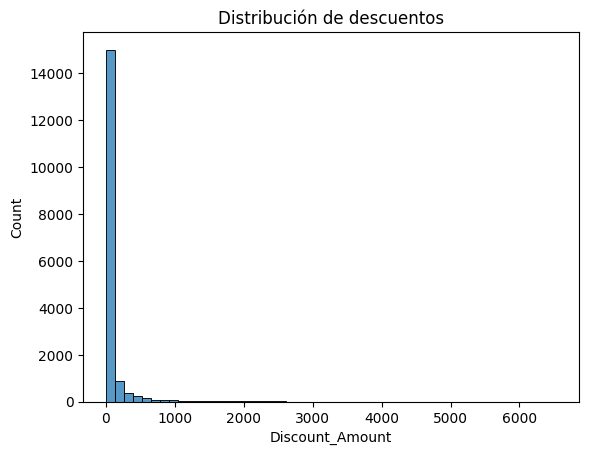

In [34]:
#Estadistica basica
print(df["Discount_Amount"].describe())
#Como se distribuyen los descuetnsos
sns.histplot(df["Discount_Amount"], bins=50)
plt.title("Distribución de descuentos")
plt.show()

Resumen:
- Es es una variable muy sesgada a la derecha por outliers
- Con muchos ceros
- Es una distribución típica de estrategia promocional selectiva, no masiva.
- Más de la mitad de las órdenes no tienen descuento
- El maximo es 6538
- La media (69) no representa bien la realidad, la realidad es 0

#### Variable: Total_Amount (monto final pagado)

count    17049.000000
mean      1277.438711
std       2358.436375
min          6.210000
25%        172.970000
50%        455.850000
75%       1267.750000
max      37852.050000
Name: Total_Amount, dtype: float64


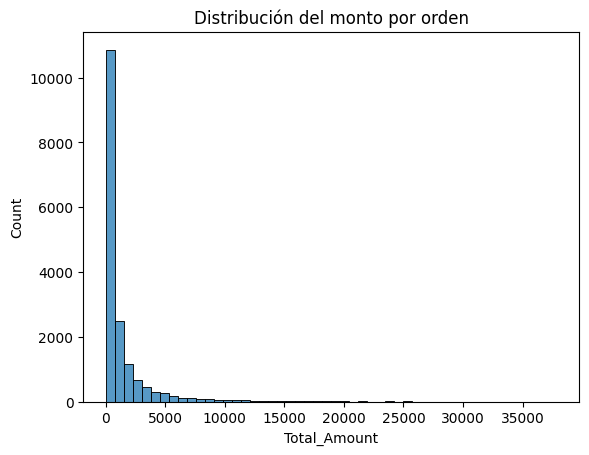

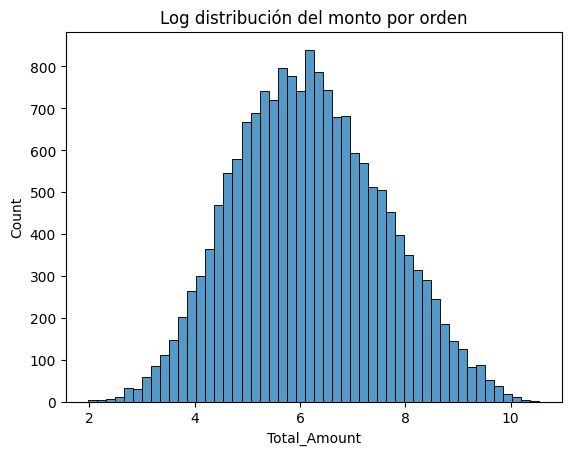

In [3]:
#Estadistica basica
print(df["Total_Amount"].describe())

# Distribucion del monto final
sns.histplot(df["Total_Amount"], bins=50)
plt.title("Distribución del monto por orden")
plt.show()


sns.histplot(np.log1p(df["Total_Amount"]), bins=50)
plt.title("Log distribución del monto por orden")
plt.show()

Resumen
- La media (1277) es casi 3 veces mayor que la mediana (455).
- Esto indica una fuerte asimetría positiva (sesgo a la derecha).
- Hay órdenes muy grandes que empujan el promedio hacia arriba.
- La mayoría de las órdenes están concentradas en montos bajos.
- Existen compras extremadamente altas (hasta 37k).
- El 75% de las ventas está por debajo de 1.300 Y un grupo muy pequeño genera tickets extremadamente altos. Esto indica la existencia de clientes de alto valor


## Analisis exploratorio del 3° Bloque: Comportamiento digital
   - Device_Type
   - Session_Duration
   - Pages_Viewed

#### Variable: Device_Type (categorica)
Qué queremos entender?
- Desde qué dispositivos navegan
- Si hay predominancia clara (ej. Mobile > Desktop)
- Si está equilibrado o concentrado

Device_Type
Mobile     9543
Desktop    5845
Tablet     1661
Name: count, dtype: int64
Device_Type
Mobile     0.559740
Desktop    0.342835
Tablet     0.097425
Name: proportion, dtype: float64


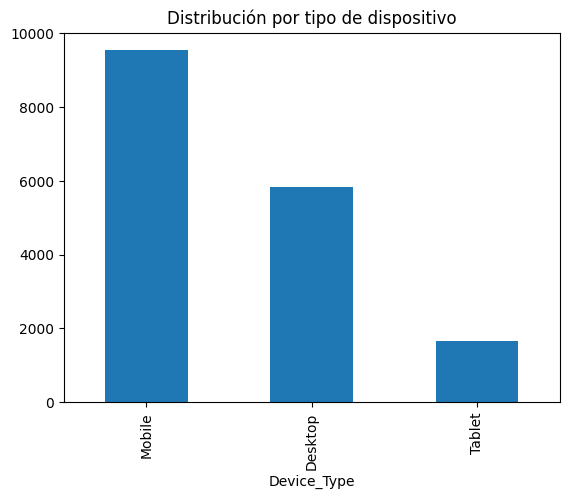

In [5]:
#Grafico de barras
print(df["Device_Type"].value_counts())
print(df["Device_Type"].value_counts(normalize=True))

df["Device_Type"].value_counts().plot(kind="bar")
plt.title("Distribución por tipo de dispositivo")
plt.show()

Resumen:
- Predomina el uso del Mobile (56%), lo que indica un comportamiento mas impulsivo o de navegacion rapida
- Pero el desktop sigue siendo relevante, un 34% no es menor. Esto sugiere que: Hay usuarios que prefieren comprar desde computadora. Posiblemente decisiones más analíticas o compras de mayor valor.

### Variable: Session_Duration_Minutes (numérica)

Queremos entender:
- Cuánto tiempo pasan los usuarios
- Si hay sesiones muy cortas predominantes
- Si existen outliers (sesiones extremadamente largas)

count    17049.000000
mean        14.535633
std          2.925524
min          4.000000
25%         13.000000
50%         15.000000
75%         17.000000
max         26.000000
Name: Session_Duration_Minutes, dtype: float64


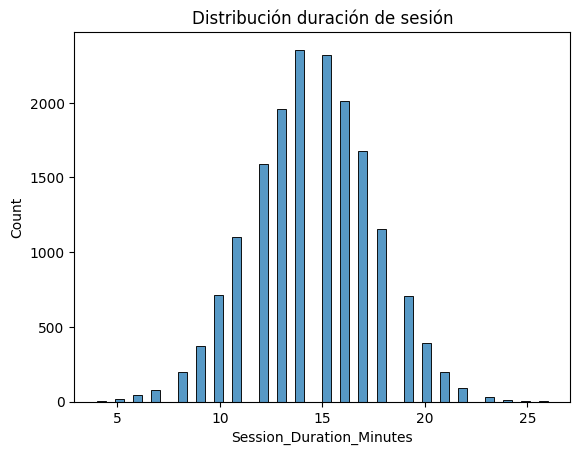

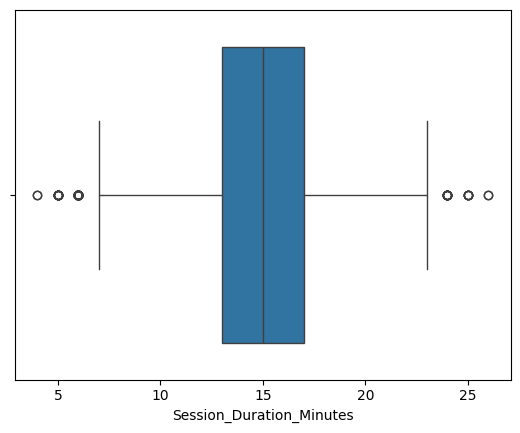

In [8]:
#Descripcion estadistica basica
print(df["Session_Duration_Minutes"].describe())

sns.histplot(df["Session_Duration_Minutes"], bins=50)
plt.title("Distribución duración de sesión")
plt.show()

sns.boxplot(x=df["Session_Duration_Minutes"])
plt.show()

Resumen:
- La media y la mediana son bastante similares, distribucion bastante simetrica.
- El 50% de las sesiones está entre 13 y 17 minutos.
- El rango total es relativamente corto (4 a 26 minutos).
- No hay una gran dispersión en el comportamiento de navegación.
- El max es de 26 min
- 14–15 minutos promedio en un e-commerce es bastante tiempo. Eso puede indicar: Usuarios que exploran, comparan productos, navegan varias categorías.
- No parece haber abandono inmediato masivo, no es que estan 1min y se van.


### Variable: Pages_Viewed (numérica discreta)
Queremos entender:
- Nivel de exploración dentro del sitio
- Si la mayoría ve pocas páginas
- Si hay usuarios muy activos

count    17049.000000
mean         9.003109
std          2.259954
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         18.000000
Name: Pages_Viewed, dtype: float64


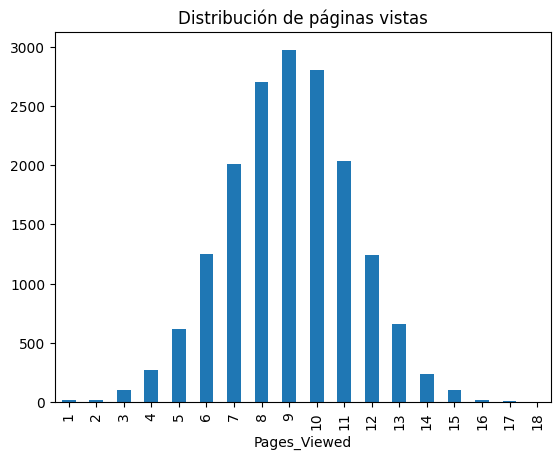

In [10]:
#Resumen estadistico simple
print(df["Pages_Viewed"].describe())
# Plot
df["Pages_Viewed"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de páginas vistas")
plt.show()

Resumen
- Distribución muy equilibrada
- El 50% de los usuarios ve entre 7 y 11 páginas.
- La SD es relativamente pqeueño, por lo que la mayoria se comporta de forma similar
- El mínimo es 1 página, pero el promedio es 9. Si hubiera mucha mas variabilidad, la media estaría más cerca de 1–3 páginas, pero no. Parece que los usuarios realmente navegan.
- Los usuarios exploran toda la pag.
- Si lo conectamos por la duracion de la sesion 14.5 min promedio / 9 pag promedio, muestra que en aprox/promedio 1.6 min los usuarios ven la pag. Lo cual es bastante razonable porque es leer la descripcion, ver imagen, ver precio.


## Analisis exploratorio del 4° Bloque: Experiencia post-compra
   - Delivery_Time
   - Customer_Rating
   - Is_Returning_Customer

### Variable: Delivery_Time_Days (numérica)
Qué queremos entender
- En cuántos días se entrega en promedio?
- Hay mucha variabilidad?
- Existen entregas extremadamente lentas?
- Es consistente el servicio logístico?

count    17049.000000
mean         6.503607
std          3.488787
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         25.000000
Name: Delivery_Time_Days, dtype: float64


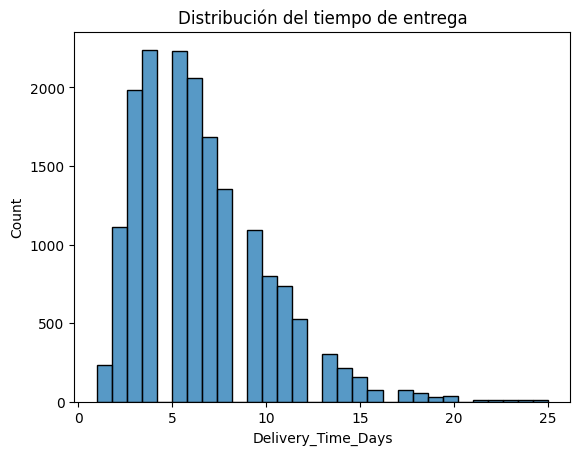

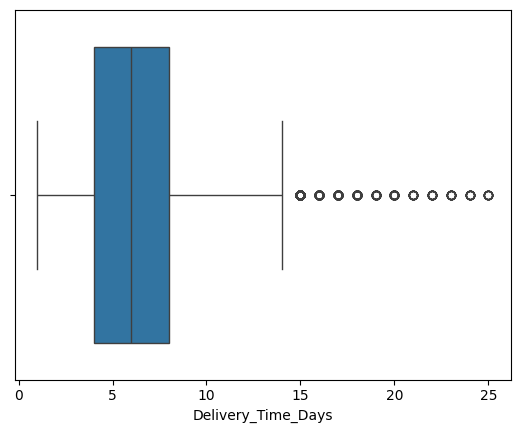

In [11]:
#Estadistica basica
print(df["Delivery_Time_Days"].describe())

#Plot
sns.histplot(df["Delivery_Time_Days"], bins=30)
plt.title("Distribución del tiempo de entrega")
plt.show()

sns.boxplot(x=df["Delivery_Time_Days"])
plt.show()

### Resumen

- En promedio, el pedido tarda 6-7 días en entregarse.
- La media (6.5) y la mediana (6) son muy parecidas. La distribución es bastante simétrica.
- El sd es de 3.48 dias, lo que implica que las entregas van entre  3-10 dias. 
- Pero existen entregas extremadamentes lentas. Max 25 dias, lo que implia 4 veces la mediana.
- Aunque sean pocos casos, pueden afectar fuertemente la experiencia del cliente.
- Esta es una variable importnte a revisar para la recompra

### Variable: Customer_Rating (numérica discreta 1-5)
Qué queremos entender
- Qué tan satisfechos están los clientes?
- Está concentrado en 4 y 5?
- Hay muchas malas experiencias?

count    17049.000000
mean         3.899408
std          1.128803
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Customer_Rating, dtype: float64


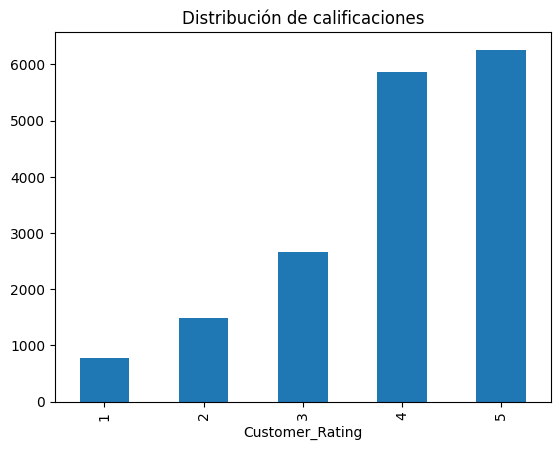

In [13]:
# Descripcion general
print(df["Customer_Rating"].describe())
#Plot
df["Customer_Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de calificaciones")
plt.show()

Resumen
- Con una media de 3.9 sobre 5, la satisfacción general es buena.
- La mediana en 4 refuerza que la experiencia tipica es positiva
- El rango intercuartílico (3 a 5) dice que el 50% central de las calificaciones está entre 3 y 5, es decir  que ,a mayoría de las compras reciben buenas valoraciones.
-  Hay malas experiencias, pero no dominnan la distribucion

### Variable: Is_Returning_Customer (booleana)
Qué queremos entender

- Qué proporción recompra?
- Está equilibrado o concentrado?
- Es un negocio de recurrencia o transaccional?

Is_Returning_Customer
True     15039
False     2010
Name: count, dtype: int64


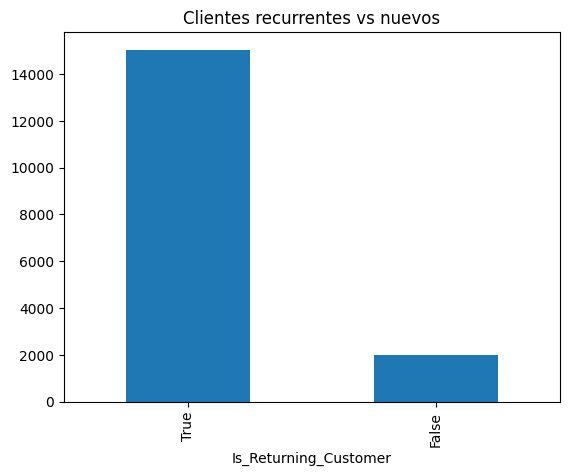

In [14]:
print(df["Is_Returning_Customer"].value_counts())
df["Is_Returning_Customer"].value_counts(normalize=True)

df["Is_Returning_Customer"].value_counts().plot(kind="bar")
plt.title("Clientes recurrentes vs nuevos")
plt.show()

Resumen:
- Esta desbalanceado con 88.2% clientes recurrentes  y solo 11.8% nuevos
- Posiblemente este inflada por clientes que compran varias veces.
- El negocio muestra alta recurrencia a nivel de órdenes, aunque a nivel cliente aproximadamente el 18% realiza una sola compra.

## Conclusiones generales del EDA

### 01. Perfil del cliente
- La edad promedio es ~35 años, con concentración entre 26 y 42, es decir un público adulto joven.
- Distribución de género equilibrada (50% Female, 48% Male).
- El negocio opera en 10 ciudades, con fuerte concentración en Istanbul (≈26% de las órdenes).
- No se observan problemas de calidad de datos (sin nulos ni duplicados).


### 02. Comportamiento de compra

- Las órdenes están bastante equilibradas entre categorías (no hay una categoría dominante en volumen).
- Sin embargo, los precios unitarios muestran alta asimetría positiva.
- Electronics tiene precios significativamente más altos que el resto.
- Quantity está acotada entre 1 y 5 unidades (media ≈3).
- El 50% de las órdenes no tiene descuento.
- Total_Amount presenta fuerte asimetría, donde pocas compras muy grandes explican gran parte del ingreso.


### 03. Comportamiento digital

- Predominio claro de Mobile (~56%), seguido por Desktop (~34%).
- Session_Duration promedio ≈14.5 minutos, distribución bastante compacta.
- Pages_Viewed promedio ≈9 páginas.
- No se observan outliers extremos en comportamiento digital.


### 04. Experiencia post-compra

- Delivery_Time promedio ≈6.5 días, con algunos casos extremos hasta 25 días.
- Customer_Rating promedio ≈3.9/5, concentrado en valores altos, satisfacción relativamente buena
- 88% de las órdenes corresponden a clientes recurrentes.
- Sin embargo, a nivel cliente, ~18% realiza una única compra.


### Conclusión Global del EDA

El dataset presenta:

- Buena calidad de datos (sin inconsistencias).
- Alta concentración de facturación en órdenes de alto valor.
- Recurrencia elevada, aunque influenciada por clientes con múltiples compras.
- Perfil demográfico y digital bastante equilibrado.
- Estructura comercial donde el precio unitario parece jugar un rol más relevante que la cantidad

bueno achora quiero emjpezar un segundo notebook primero abriendo el archivo y todo eso pero ahora quiero primero determinar cual es la problematica que voy a anfrentear/resolver cual seria para vos considerando toda esta info que estuvimos viendo con los analisis univariados?